# 📋Tp 10 parte2 de preguntas sobre felinos📋

In [2]:
import pandas as pd

In [3]:
import plotly.express as px

In [4]:
import folium

In [5]:
feli = pd.read_csv("felinos_filtrado.csv")

### pregunta 1 ¿Cómo cambió la cantidad de avistamientos de felinos durante los últimos meses del año más reciente?

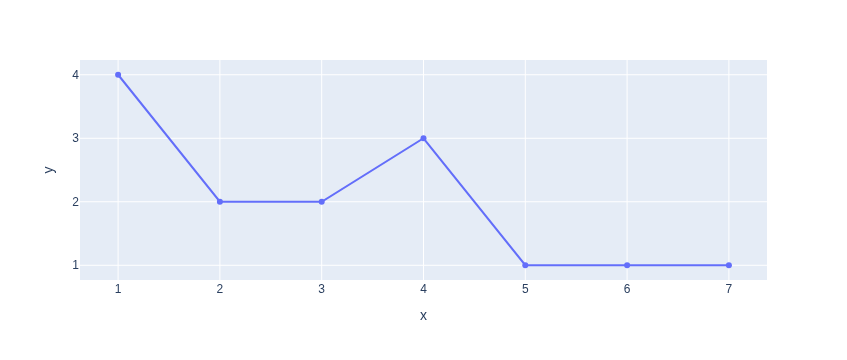

In [20]:
anio_actual = feli["year"].max()
feli_actual = feli[feli["year"] == anio_actual]
meses_actual = feli_actual["month"].value_counts().sort_index()

fig = px.line(
    x=meses_actual.index,
    y=meses_actual.values,
    markers=True
)

fig.show()

### pregunta2 ¿Cómo cambia la cantidad de avistamientos durante los meses en el año 2010? mostrar gráfico gráfico de líneas

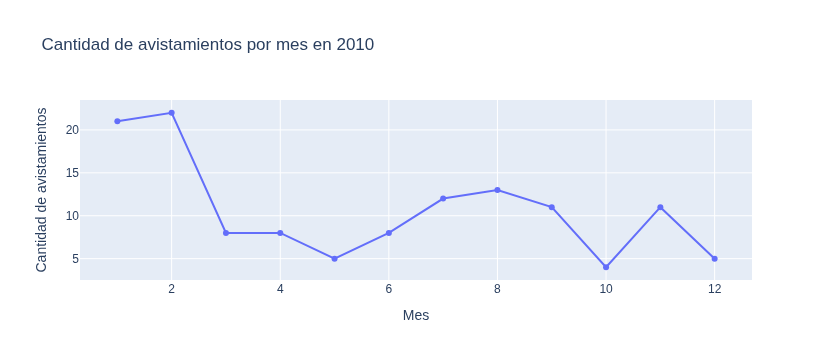

In [25]:
feli_2010 = feli[feli["year"] == 2010]
meses_2010 = feli_2010["month"].value_counts().sort_index()

fig = px.line(
    x=meses_2010.index,
    y=meses_2010.values,
    title="Cantidad de avistamientos por mes en 2010",
    labels={
        "x": "Mes",
        "y": "Cantidad de avistamientos"
    },
    markers=True
)

fig.show()

### pregunta 3 ¿Es verdad que Santa Cruz es la segunda provincia con más avistajes registrados? Filtro

In [9]:
provincias = feli["stateProvince"].value_counts()
provincias.head(3)

stateProvince
Misiones      1253
Santa Cruz     313
Corrientes     178
Name: count, dtype: int64

### pregunta4 ¿Cuántas especies diferentes hay registradas en el archivo? cálculo

In [10]:
feli["species"].nunique()

9

### pregunta 5 ¿En qué meses del año se registraron más avistamientos de felinos? Gráfico de barras

In [11]:
meses = feli["month"].value_counts().sort_index()

fig = px.bar(
    x=meses.index,
    y=meses.values,
    title="Cantidad de avistamientos por mes",
    labels={
        "x": "Mes",
        "y": "Cantidad de avistamientos"
    }
)

fig.show()

### pregunta 6 ¿Qué provincias tienen la mayor cantidad de felinos registrados? Gráfico de barra

In [12]:
provincias = feli["stateProvince"].value_counts()

fig = px.bar(
    x=provincias.index,
    y=provincias.values,
    title="Cantidad de avistamientos por provincia",
    labels={
        "x": "Provincia",
        "y": "Cantidad de avistamientos"
    }
)

fig.show()

### pregunta7 ¿Cuales fueron las 3 especies registradas en las provincias que concentran la mayor cantidad de avistamientos? 

In [36]:
feli_top = feli[
    (feli["stateProvince"] == "Misiones") |
    (feli["stateProvince"] == "Santa Cruz") |
    (feli["stateProvince"] == "Corrientes")
]

top_especies = feli_top["species"].value_counts().head(3)

print(top_especies)

species
Puma concolor        1135
Puma yagouaroundi     318
Panthera onca         164
Name: count, dtype: int64


### pregunta 8 ¿Cuál es el mes con mayor y menor porcentaje de avistamientos? gráfico de torta

In [14]:
meses = feli["month"].value_counts().sort_index()

porcentajes = (
    meses / meses.sum() * 100
)
fig = px.pie(
    values=meses.values,
    names=meses.index,
    title="Porcentaje de avistamientos por mes"
)

fig.show()

### pregunta9 ¿Cómo se distribuyen geográficamente los registros de la especie Panthera onca? Mapa

In [15]:
# Crear un nuevo mapa
mapa_panthera = generar_mapa()

panthera = feli[
    feli["species"] == "Panthera onca"
]

def agregar_marca_panthera(row):
    
    folium.Marker(
        [row["lat"], row["lng"]],
        
        popup=(
            "Especie: " + str(row["species"]) +
            "<br>Provincia: " + str(row["stateProvince"])
        ),
        
        icon=folium.Icon()
        
    ).add_to(mapa_panthera)

panthera.apply(
    agregar_marca_panthera,
    axis=1
)

mapa_panthera

NameError: name 'generar_mapa' is not defined

### pregunta10 Mapa general con todas las especies de “Puma” 

In [26]:
def generar_mapa():
    
    attr = (
        '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> '
        'contributors, &copy; <a href="https://cartodb.com/attributions">CartoDB</a>'
    )

    tiles = 'https://wms.ign.gob.ar/geoserver/gwc/service/tms/1.0.0/capabaseargenmap@EPSG%3A3857@png/{z}/{x}/{-y}.png'

    m = folium.Map(
        location=(-33.457606, -65.346857),
        control_scale=True,
        zoom_start=5,
        name='es',
        tiles=tiles,
        attr=attr
    )
    
    return m

mapa = generar_mapa()
pumas = feli[feli["genus"] == "Puma"]

def agregar_marca_puma(row):
    
    folium.Marker(
        [row["lat"], row["lng"]],
        popup=row["species"],
        icon=folium.Icon()
        
    ).add_to(mapa)

pumas.apply(agregar_marca_puma, axis=1)

mapa